# Scenario 2: Volume shock and re-optimisation

This notebook tests how the delivery plan is affected when delivery volume suddenly increases. Extra pallet volume is added to selected stops to simulate a capacity shock. The purpose is to see whether the existing fleet can handle the extra load, or whether deliveries need to be moved between vehicles. The scenario is relevant for short-term planning, where planners often need to respond quickly to demand changes. Results should be seen as a simplified proof of concept.

## Import libraries

Pandas and NumPy are used for data preparation and calculations. Matplotlib is used for visualisation. Google OR-Tools is used to re-optimise deliveries across available vehicles.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ortools.constraint_solver import pywrapcp, routing_enums_pb2

C:\Users\tuvap\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\tuvap\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## Define scenario settings and column names

All key variables are collected at the start of the notebook so the scenario can be adjusted easily if needed. These settings define the selected date, number of vehicles, stop limits, pallet shock size, and vehicle capacity assumptions. Keeping assumptions in one place makes it easier to test different operational cases and dates.

In [2]:
customerColumn = "Kundenr"
shiftColumn = "Kjøreskift ID"
dateColumn = "Dato"
timeColumn = "time_idx"
startWindow = "Leveringsvindu fra"
endWindow = "Leveringsvindu til"
startColumn = "Start Levering"
volumeColumn = "Levert volum (m3)"
predColumn = "predikert_leveringstid"

chosenDate = "2025-04-22"

fromHour = 8
toHour = 16
vehicleCount = 5
maxStops = 30
extraVehicle = 1
palletVolume = 1.2
extraPalletsBiggest = 5
extraPalletsSecond = 4
truckTrailerCapacity = 42
truckOnlyCapacity = 23
distanceFactor = 2
solveTime = 10

## Load prediction, historical and shock data

The prepared prediction, historical, and shock scenario datasets are loaded and aligned so they can be used together in this analysis. Dates and column names are cleaned to ensure consistent filtering, merging, and later optimisation steps.

In [3]:
predData = pd.read_csv("predictions.csv", low_memory=False)
historyData = pd.read_csv("merged_clean_7years.csv", low_memory=False)
shockData = pd.read_csv("predictions_shock.csv", low_memory=False)

predData.columns = predData.columns.str.strip()
historyData.columns = historyData.columns.str.strip()
shockData.columns = shockData.columns.str.strip()

predData[dateColumn] = pd.to_datetime(predData[dateColumn], errors="coerce")
historyData[dateColumn] = pd.to_datetime(historyData[dateColumn], errors="coerce")

historyData[startColumn] = pd.to_datetime(historyData[startColumn], errors="coerce")
historyData[startWindow] = pd.to_datetime(historyData[startWindow], errors="coerce")
historyData[endWindow] = pd.to_datetime(historyData[endWindow], errors="coerce")

predData["mergeDate"] = predData[dateColumn].dt.date
historyData["mergeDate"] = historyData[dateColumn].dt.date

## Define helper functions

Helper functions are created to simplify repeated tasks in the notebook. Time values are converted to minutes because OR-Tools requires numerical input as mentioned before. Plot labels are added to make charts easier to read. Simplified customer locations are generated so the model can estimate travel distances without real GPS data. These locations are only used for demonstration purposes.

In [4]:
def toMinutes(timeValue):
    return int(timeValue.hour) * 60 + int(timeValue.minute)


def addLabels(axis, bars):
    for bar in bars:
        height = bar.get_height()

        axis.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.1f}",
            ha="center",
            va="bottom",
            fontsize=9)


def fakePoint(customerId):
    np.random.seed(int(customerId) % 100000)
    xPoint = float(np.random.uniform(0, 100))
    yPoint = float(np.random.uniform(0, 100))

    return xPoint, yPoint

## Make sure time windows are available

Valid delivery time windows are required before optimisation can be performed. If they are missing from the prediction data, they are retrieved from the historical dataset using customer ID and date. This keeps the scenario usable even when the prediction file only contains model outputs.

In [5]:
if startWindow not in predData.columns or endWindow not in predData.columns:

    windowData = historyData.dropna(subset=[startWindow, endWindow])
    windowData = windowData.groupby([customerColumn, "mergeDate"], as_index=False).agg({startWindow: "min", endWindow: "max"})
    predData = predData.merge(windowData, on=[customerColumn, "mergeDate"], how="left")

predData[startWindow] = pd.to_datetime(predData[startWindow], errors="coerce")
predData[endWindow] = pd.to_datetime(predData[endWindow], errors="coerce")

## Merge prediction data with historical operational data

The prediction data is merged with the operational dataset so each stop includes both predicted service time and the planning information needed for optimisation. The selected date and time period are then filtered. This creates one clean scenario dataset for the next steps.

In [6]:
historySmall = historyData[[
    customerColumn,
    "mergeDate",
    shiftColumn,
    startColumn,
    volumeColumn]].copy()

data = predData.merge(historySmall,on=[customerColumn, "mergeDate"],how="left")
data = data.dropna(subset=[shiftColumn, startColumn]).copy()
data = data.rename(columns={volumeColumn: "historyVolume"})

chosenDate = pd.to_datetime(chosenDate).date()

rows = data[data["mergeDate"] == chosenDate].copy()
rows["historyVolume"] = pd.to_numeric(rows["historyVolume"], errors="coerce").fillna(0)
rows = rows.dropna(subset=[startWindow, endWindow]).copy()
rows = rows[rows[startWindow].dt.hour.between(fromHour, toHour)].copy()

if len(rows) == 0:
    raise ValueError("No rows found")

print("Rows used:", len(rows))

Rows used: 90


## Create volume shock

After preparing the scenario data, the vehicles with the highest total volume are selected. This focuses the test on the part of the plan where capacity pressure is most relevant. For each selected vehicle, the largest stops are identified and given extra pallet volume. This creates a controlled volume shock that can be compared with the original plan. The result is a before-and-after volume table for each vehicle, which is used in the next plot and later in the optimisation.

In [7]:
volumePerVehicle = (rows.groupby(shiftColumn)["historyVolume"].sum().sort_values(ascending=False))
vehicleOrder = volumePerVehicle.head(vehicleCount).index.tolist()
rows = rows[rows[shiftColumn].isin(vehicleOrder)].copy()
extraVolumeBiggest = extraPalletsBiggest * palletVolume
extraVolumeSecond = extraPalletsSecond * palletVolume

stopVolume = (
    rows.groupby([shiftColumn, customerColumn, timeColumn, startWindow, endWindow], as_index=False)
    .agg(baseVolume=("historyVolume", "sum")))

stopVolume["rank"] = stopVolume.groupby(shiftColumn)["baseVolume"].rank(
    method="first",
    ascending=False)

stopVolume["extraVolume"] = 0.0
stopVolume.loc[stopVolume["rank"] == 1, "extraVolume"] = extraVolumeBiggest
stopVolume.loc[stopVolume["rank"] == 2, "extraVolume"] = extraVolumeSecond
stopVolume["shockVolume"] = stopVolume["baseVolume"] + stopVolume["extraVolume"]

vehicleVolume = (
    stopVolume.groupby(shiftColumn, as_index=False)
    .agg(volumeBefore=("baseVolume", "sum"), volumeAfter=("shockVolume", "sum")))

vehicleVolume["order"] = vehicleVolume[shiftColumn].apply(lambda vehicle: vehicleOrder.index(vehicle))
vehicleVolume = vehicleVolume.sort_values("order").reset_index(drop=True)

## Visualise vehicle volume before and after shock

The first plot compares total vehicle load before and after the shock. Capacity lines are included to show whether any vehicles move close to or above normal operating limits. This gives an early view of whether the changed demand creates a problem that may require reallocation or not. 

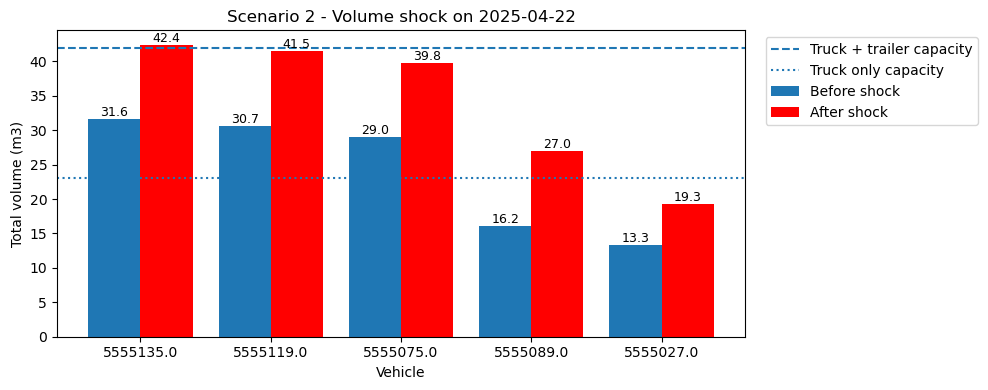

In [9]:
xValues = np.arange(len(vehicleVolume))
fig, axis = plt.subplots(figsize=(10, 4))
barsBefore = axis.bar(xValues - 0.2, vehicleVolume["volumeBefore"], 0.4, label="Before shock")
barsAfter = axis.bar( xValues + 0.2, vehicleVolume["volumeAfter"], 0.4, label="After shock", color = "red")
axis.axhline(truckTrailerCapacity, linestyle="--", label="Truck + trailer capacity")
axis.axhline(truckOnlyCapacity, linestyle=":", label="Truck only capacity")
axis.set_xticks(xValues)
axis.set_xticklabels(vehicleVolume[shiftColumn].astype(str))
axis.set_xlabel("Vehicle")
axis.set_ylabel("Total volume (m3)")
axis.set_title(f"Scenario 2 - Volume shock on {chosenDate}")
axis.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
addLabels(axis, barsBefore)
addLabels(axis, barsAfter)
plt.tight_layout()
plt.show()

## Add shock service-time predictions

When delivery volume increases, service time may also increase. Updated service-time predictions are therefore merged into the scenario data using customer and stop identifiers. This ensures that the optimisation reflects both higher load and the extra handling time that larger deliveries may create. Without this step, the model would only react to capacity pressure and ignore time pressure.

In [11]:
possibleShockColumns = [
    "predikert_leveringstid_shock",
    "predicted_delivery_time_min_shock",
    "delivery_time_min_shock",
    "predicted_shock",
    "shock_predicted_minutes"]

shockColumn = None

for column in possibleShockColumns:
    if column in shockData.columns:
        shockColumn = column
        break

if shockColumn is None:
    raise ValueError("Could not find shock prediction column")

rows[timeColumn] = pd.to_numeric(rows[timeColumn], errors="coerce")
shockData[timeColumn] = pd.to_numeric(shockData[timeColumn], errors="coerce")

rows[customerColumn] = pd.to_numeric(rows[customerColumn], errors="coerce")
shockData[customerColumn] = pd.to_numeric(shockData[customerColumn], errors="coerce")

shockSmall = shockData[[customerColumn, timeColumn, shockColumn]]
rows = rows.merge( shockSmall, on=[customerColumn, timeColumn], how="left")
rows["timeAfter"] = pd.to_numeric(rows[shockColumn], errors="coerce")

print("Using shock column:", shockColumn)

Using shock column: predikert_leveringstid_shock


## Prepare stop-level data for optimisation

The data is grouped to stop level so each delivery appears once with the main inputs needed by the solver. Shocked volume values are kept together with time windows and updated service times. This creates a cleaner optimisation dataset and avoids duplicate rows. To keep the prototype manageable, only the most relevant stops are included, while still giving the main planning challenge.

In [12]:
stops = (
    rows.groupby([shiftColumn, customerColumn, timeColumn, startWindow, endWindow], as_index=False)
    .agg(baseVolume=("historyVolume", "sum"), timeAfter=("timeAfter", "mean")))

stops["rank"] = stops.groupby(shiftColumn)["baseVolume"].rank(method="first", ascending=False)
stops["extraVolume"] = 0.0
stops.loc[stops["rank"] == 1, "extraVolume"] = extraVolumeBiggest
stops.loc[stops["rank"] == 2, "extraVolume"] = extraVolumeSecond

stops["shockVolume"] = stops["baseVolume"] + stops["extraVolume"]
stops = stops.sort_values("shockVolume", ascending=False).head(maxStops).reset_index(drop=True)

if len(stops) == 0:
    raise RuntimeError("No stops to optimise")

stops["startMin"] = stops[startWindow].apply(toMinutes).astype(int)
stops["endMin"] = stops[endWindow].apply(toMinutes).astype(int)

volumeBeforeDict = stops.groupby(shiftColumn)["shockVolume"].sum().to_dict()
customerList = stops[customerColumn].astype(int).tolist()

## Create simplified travel time matrix

As in the previous scenario, a simplified travel-time matrix is created between the depot and selected customers. This provides the movement input required by the solver without using real adresses. The same simplification is reused here so the analysis can focus on how capacity shocks affect vehicle allocation rather than detailed route geography.

In [13]:
points = np.array([fakePoint(customerId) for customerId in customerList], dtype=float)

depotPoint = points.mean(axis=0)
allPoints = np.vstack([depotPoint, points])

nodeCount = len(allPoints)
travelTime = [[0] * nodeCount for _ in range(nodeCount)]

for startStop in range(nodeCount):
    for endStop in range(nodeCount):

        if startStop != endStop:
            startPoint = allPoints[startStop]
            endPoint = allPoints[endStop]
            xDistance = startPoint[0] - endPoint[0]
            yDistance = startPoint[1] - endPoint[1]
            distance = (xDistance ** 2 + yDistance ** 2) ** 0.5
            travelTime[startStop][endStop] = int(distance * 0.5 * distanceFactor)

## Prepare optimisation input lists

Also here as previous scenario, the processed data is converted into lists because this is the structure required by OR-Tools. Here the inputs are extended to include shocked stop volumes, updated service times, delivery window limits, and the available fleet size. A depot node is added first. This prepares the final inputs for testing whether an extra vehicle can improve the shocked plan.

In [14]:
volumeList = [0.0] + stops["shockVolume"].tolist()

timeList = [0] + (
    pd.to_numeric(stops["timeAfter"], errors="coerce")
    .fillna(0)
    .round()
    .astype(int)
    .tolist())

startList = [0] + stops["startMin"].tolist()
endList = [24 * 60] + stops["endMin"].tolist()

stopCount = len(stops)
totalVehicles = len(vehicleOrder) + extraVehicle

## Build capacity model in OR-Tools

OR-Tools is used again, but here the model is extended from route sequencing to fleet capacity planning. Multiple vehicles are included, each with volume limits, so stops can be reassigned across the fleet after the shock. Fixed vehicle costs are added to avoid unnecessary vehicle use, while the extra vehicle is made available as a helping option. This allows the model to evaluate whether overload should be reduced through reallocation or by using additional capacity.

In [15]:
manager = pywrapcp.RoutingIndexManager(stopCount + 1, totalVehicles, 0)
routing = pywrapcp.RoutingModel(manager)

for vehicleNumber in range(totalVehicles):
    routing.SetFixedCostOfVehicle(200000, vehicleNumber)

extraVehicleNumber = totalVehicles - 1
routing.SetFixedCostOfVehicle(10000, extraVehicleNumber)


def travelCallback(startIndex, endIndex):
    startStop = manager.IndexToNode(startIndex)
    endStop = manager.IndexToNode(endIndex)
    return travelTime[startStop][endStop]

travelIndex = routing.RegisterTransitCallback(travelCallback)
routing.SetArcCostEvaluatorOfAllVehicles(travelIndex)


def volumeCallback(startIndex):
    stopNumber = manager.IndexToNode(startIndex)
    return int(volumeList[stopNumber] * 1000)


volumeIndex = routing.RegisterUnaryTransitCallback(volumeCallback)
routing.AddDimensionWithVehicleCapacity(
    volumeIndex,
    0,
    [int(truckTrailerCapacity * 1000)] * totalVehicles,
    True,
    "Capacity")

capacityDim = routing.GetDimensionOrDie("Capacity")

## Add soft capacity and time constraints

Capacity and time constraints are added to keep the solution operationally realistic. A soft limit is used at the truck-only capacity level, meaning vehicles may exceed this level, but with a penalty cost. This gives the model flexibility to handle the shock scenario without failing immediately, while still preferring balanced solutions. Delivery time windows are also implemented, so any suggested routes must remain feasible in both load and timing.

In [16]:
softLimit = int(truckOnlyCapacity * 1000)
penalty = 5000

for vehicleNumber in range(totalVehicles):
    endIndex = routing.End(vehicleNumber)
    capacityDim.SetCumulVarSoftUpperBound(endIndex, softLimit, penalty)
    routing.AddVariableMinimizedByFinalizer(capacityDim.CumulVar(endIndex))

def timeCallback(startIndex, endIndex):
    startStop = manager.IndexToNode(startIndex)
    endStop = manager.IndexToNode(endIndex)
    return travelTime[startStop][endStop] + timeList[startStop]

timeIndex = routing.RegisterTransitCallback(timeCallback)
routing.AddDimension( timeIndex, 60, 24 * 60, False, "Time")
timeDim = routing.GetDimensionOrDie("Time")

for stopNumber in range(stopCount + 1):
    stopIndex = manager.NodeToIndex(stopNumber)
    timeDim.CumulVar(stopIndex).SetRange(startList[stopNumber], endList[stopNumber])

## Solve the optimisation problem

With the model fully defined, the solver searches for a plan that balances travel time, capacity pressure, vehicle use, and delivery-window feasibility. An initial solution is created first, and then improved through local search within the allowed runtime. If no solution is found, it indicates that the selected scenario settings are too restrictive under the shocked demand conditions.

In [17]:
params = pywrapcp.DefaultRoutingSearchParameters()
params.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
params.local_search_metaheuristic = routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
params.time_limit.FromSeconds(solveTime)
solution = routing.SolveWithParameters(params)

if solution is None:
    raise RuntimeError("No OR-Tools solution found")

## Extract vehicle volumes after optimisation

After a solution is found, the assigned stops for each vehicle are read from the solver output. The shocked delivery volumes on those stops are then summed for every route. This gives the final load per vehicle after reallocation and shows how the optimiser redistributed demand across the fleet.

In [18]:
volumeAfter = []

for vehicleNumber in range(totalVehicles):
    routeIndex = routing.Start(vehicleNumber)
    routeVolume = 0.0

    while not routing.IsEnd(routeIndex):
        stopNumber = manager.IndexToNode(routeIndex)

        if stopNumber != 0:
            routeVolume += float(volumeList[stopNumber])
        routeIndex = solution.Value(routing.NextVar(routeIndex))
    volumeAfter.append(routeVolume)

## Visualise volume before and after optimisation

The final plot compares vehicle load before and after optimisation. The extra vehicle is included to show whether more fleet capacity was used to handle part of the shocked demand. Capacity lines make it easier to see whether overload was reduced. This is the main result of Scenario 2, because it shows whether reallocation can improve robustness when volume suddenly increases. As seen below, most vehicles are moved close to or below the truck-only capacity limit, while only small overload remains. This suggests that the optimiser found a more cost-efficient plan where more vehicles can operate without trailers, which may lower operating cost.

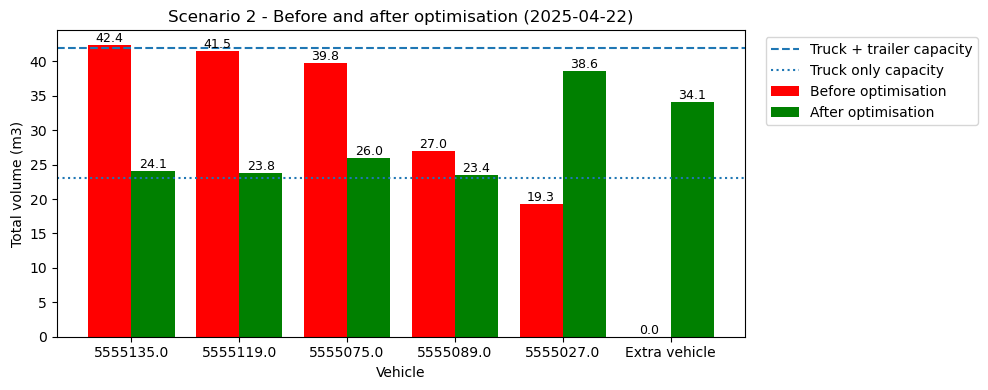

In [20]:
labels = [str(vehicle) for vehicle in vehicleOrder] + ["Extra vehicle"]
volumeBefore = [float(volumeBeforeDict.get(vehicle, 0.0)) for vehicle in vehicleOrder] + [0.0]
volumeAfterPlot = volumeAfter[:len(vehicleOrder)] + [volumeAfter[-1]]
xValues = np.arange(len(labels))
fig, axis = plt.subplots(figsize=(10, 4))
barsBefore = axis.bar( xValues - 0.2, volumeBefore, 0.4, label="Before optimisation", color = "red")
barsAfter = axis.bar( xValues + 0.2, volumeAfterPlot, 0.4, label="After optimisation", color = "green")
axis.axhline(truckTrailerCapacity, linestyle="--", label="Truck + trailer capacity")
axis.axhline(truckOnlyCapacity, linestyle=":", label="Truck only capacity")
axis.set_xticks(xValues)
axis.set_xticklabels(labels)
axis.set_xlabel("Vehicle")
axis.set_ylabel("Total volume (m3)")
axis.set_title(f"Scenario 2 - Before and after optimisation ({chosenDate})")
axis.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
addLabels(axis, barsBefore)
addLabels(axis, barsAfter)
plt.tight_layout()
plt.show()